# 3시드 OOF·Public 회고 노트북

## §0 머리말과 재현성 계약

이 노트북은 감사 기준일(2026-08-18)까지 완료된 3시드 실험 전체를 회고하고, OOF AUC와 Public AUC의 관계를 검증해 다음 실험 권고까지 잇는다.
분석 모집단은 실행 id 목록이 아니라 감사 문서가 고정한 판별 규칙으로 `mlflow.db`에서 재도출하며, 재도출 건수가 감사 기준과 다르면 노트북 실행이 즉시 실패한다.

재현성 계약은 다음과 같다.

- 입력은 `mlflow.db`, `artifacts/pool.yaml`, `artifacts/champion.yaml` 세 파일뿐이고, 하나라도 없으면 생성하지 않고 즉시 중단한다.
- MLflow 데이터베이스는 sqlite 읽기 전용(`mode=ro`) 연결로만 열고, `mlflow` 패키지는 import 하지 않는다.
- `AUDIT_CUTOFF`(KST 2026-08-19 00:00) 이후에 시작된 실행은 건수만 보고하고 모든 분석에서 제외한다.

관련 문서: [지도 #208](https://github.com/tmheo/predicting-smartphone-addiction/issues/208),
[모집단 감사 문서](../docs/research/mlflow-3seed-population-audit.md),
[ADR 0001 실험 채택 판정 계약](../docs/adr/0001-experiment-adoption-contract.md),
[이 노트북의 구현 명세](../docs/specs/oof-public-retrospective-notebook.md).

In [1]:
from datetime import datetime
from pathlib import Path
from zoneinfo import ZoneInfo


def _find_repo_root() -> Path:
    here = Path.cwd().resolve()
    for candidate in (here, *here.parents):
        if (candidate / "pyproject.toml").is_file():
            return candidate
    raise FileNotFoundError("pyproject.toml이 있는 저장소 루트를 찾지 못해 중단한다")


KST = ZoneInfo("Asia/Seoul")
REPO_ROOT = _find_repo_root()
MLFLOW_DB_PATH = REPO_ROOT / "mlflow.db"
POOL_PATH = REPO_ROOT / "artifacts/pool.yaml"
CHAMPION_PATH = REPO_ROOT / "artifacts/champion.yaml"
AUDIT_CUTOFF = datetime(2026, 8, 19, 0, 0, 0, tzinfo=KST)
EXPERIMENT_NAME = "predicting-smartphone-addiction"

In [2]:
import sqlite3

import pandas as pd

pd.set_option("display.max_rows", 80)
pd.set_option("display.max_colwidth", 130)
pd.set_option("display.width", 200)

for _path in (MLFLOW_DB_PATH, POOL_PATH, CHAMPION_PATH):
    if not _path.is_file():
        raise FileNotFoundError(f"입력 파일이 없다(생성하지 않고 중단): {_path}")

connection = sqlite3.connect(f"file:{MLFLOW_DB_PATH}?mode=ro", uri=True)
try:
    experiments = pd.read_sql("SELECT experiment_id, name FROM experiments", connection)
    _matched = experiments.loc[experiments["name"] == EXPERIMENT_NAME, "experiment_id"]
    if len(_matched) != 1:
        raise RuntimeError(f"실험 이름 {EXPERIMENT_NAME!r} 조회 결과가 1건이 아니다: {len(_matched)}건")
    EXPERIMENT_ID = int(_matched.iloc[0])
    runs = pd.read_sql(
        "SELECT run_uuid, status, start_time FROM runs WHERE experiment_id = ?",
        connection,
        params=(EXPERIMENT_ID,),
    )
    params_long = pd.read_sql("SELECT run_uuid, key, value FROM params", connection)
    metrics_long = pd.read_sql("SELECT run_uuid, key, value FROM latest_metrics", connection)
    tags_long = pd.read_sql("SELECT run_uuid, key, value FROM tags", connection)
finally:
    connection.close()

run_start_kst = runs["start_time"].map(lambda ms: datetime.fromtimestamp(ms / 1000, tz=KST))
n_excluded_after_cutoff = int((run_start_kst >= AUDIT_CUTOFF).sum())

_db_stat = MLFLOW_DB_PATH.stat()
contract_table = pd.DataFrame(
    [
        ("실행 시각(KST)", datetime.now(tz=KST).strftime("%Y-%m-%d %H:%M:%S %Z")),
        ("mlflow.db 경로", str(MLFLOW_DB_PATH)),
        ("pool.yaml 경로", str(POOL_PATH)),
        ("champion.yaml 경로", str(CHAMPION_PATH)),
        ("mlflow.db 크기", f"{_db_stat.st_size:,} bytes"),
        ("mlflow.db 수정 시각(KST)", datetime.fromtimestamp(_db_stat.st_mtime, tz=KST).strftime("%Y-%m-%d %H:%M:%S")),
        ("AUDIT_CUTOFF", AUDIT_CUTOFF.strftime("%Y-%m-%d %H:%M:%S %Z")),
        ("감사 기준일(2026-08-18) 이후 추가되어 제외된 실행 수", str(n_excluded_after_cutoff)),
    ],
    columns=["항목", "값"],
)
display(contract_table)

,항목,값
0,실행 시각(KST),2026-08-19 00:12:28 KST
1,mlflow.db 경로,/Users/taemyungheo/workspace/github/kaggle/predicting-smartphone-addiction/.claude/worktrees/issue-218-retrospective-notebook/...
2,pool.yaml 경로,/Users/taemyungheo/workspace/github/kaggle/predicting-smartphone-addiction/.claude/worktrees/issue-218-retrospective-notebook/...
3,champion.yaml 경로,/Users/taemyungheo/workspace/github/kaggle/predicting-smartphone-addiction/.claude/worktrees/issue-218-retrospective-notebook/...
4,mlflow.db 크기,"4,222,976 bytes"
5,mlflow.db 수정 시각(KST),2026-08-18 23:57:10
6,AUDIT_CUTOFF,2026-08-19 00:00:00 KST
7,감사 기준일(2026-08-18) 이후 추가되어 제외된 실행 수,0


### 원자료 적재와 모집단 재도출

`runs`, `params`, `latest_metrics`, `tags` 네 표의 SELECT만으로 실행당 한 행의 원자료(RAW)를 만들고, 감사 문서의 판별 규칙으로 P0부터 앙상블 구획까지 재도출한다.
어떤 실행도 버리지 않고 원자료 표에 보존하며, 제외는 사유 코드로만 표시한다.

In [3]:
params_wide = params_long.pivot(index="run_uuid", columns="key", values="value")
metrics_wide = metrics_long.pivot(index="run_uuid", columns="key", values="value").astype(float)
tags_wide = tags_long.pivot(index="run_uuid", columns="key", values="value")

SEED_METRICS = ["auc_oof_seed_42", "auc_oof_seed_43", "auc_oof_seed_44"]
CONFIG_ALIASES = {"exp033_lattice_te": "exp035_lattice_te"}  # 감사 문서: exp033/exp035 동일 구성 판정

raw = runs.set_index("run_uuid").join(params_wide, how="left").join(metrics_wide, how="left", rsuffix="_metric")
raw["start"] = raw["start_time"].map(lambda ms: datetime.fromtimestamp(ms / 1000, tz=KST))
raw["dirty"] = tags_wide["git_dirty"].reindex(raw.index).eq("True")
raw["run_name"] = tags_wide["mlflow.runName"].reindex(raw.index)
raw["has_git_commit_tag"] = tags_wide["git_commit"].reindex(raw.index).notna()
_ensemble_params = [c for c in params_wide.columns if str(c).startswith("ensemble.")]
raw["is_ensemble"] = raw[_ensemble_params].notna().any(axis=1) if _ensemble_params else False
raw["strict"] = raw[SEED_METRICS].notna().all(axis=1)
raw["config"] = raw["experiment"].replace(CONFIG_ALIASES)
raw["seed_range"] = raw[SEED_METRICS].max(axis=1) - raw[SEED_METRICS].min(axis=1)
raw["avg_gain"] = raw["auc_oof"] - raw[SEED_METRICS].mean(axis=1)
raw.loc[~raw["strict"], ["seed_range", "avg_gain"]] = float("nan")
raw["series"] = raw["model.kind"].fillna("(model.kind 기록 없음)")
raw["short"] = raw["experiment"].str.extract(r"^(exp\d+)")[0].fillna(raw["experiment"])

p0 = raw[raw["start"] < AUDIT_CUTOFF].copy()

p1 = p0[(p0["status"] == "FINISHED") & (p0["seeds"] == "42,43,44")].copy()
p2 = p1[p1["strict"]].copy()

representative_ids, dirty_exception_ids = [], []
for _cfg, _group in p1.groupby("config"):
    _clean = _group[~_group["dirty"]]
    _pool = _clean if len(_clean) else _group
    representative_ids.append(_pool.sort_values("start").index[-1])
    if not len(_clean):
        dirty_exception_ids.append(representative_ids[-1])
p3 = p1.loc[representative_ids].copy()
p3["dirty_rep_exception"] = p3.index.isin(dirty_exception_ids)

transfer_runs = p1[p1["public_auc"].notna()].copy()
ensemble_runs = p0[p0["is_ensemble"] & (p0["status"] == "FINISHED")].copy()

in_p1 = pd.Series(p0.index.isin(p1.index), index=p0.index)
in_p3 = pd.Series(p0.index.isin(p3.index), index=p0.index)
reason_rules = {
    "NOT_FINISHED": p0["status"].ne("FINISHED"),
    "SINGLE_SEED": p0["status"].eq("FINISHED") & p0["seeds"].eq("42"),
    "LEGACY_FORMAT": in_p1 & ~p0["strict"],
    "DUPLICATE": in_p1 & ~in_p3,
    "DIRTY": in_p1 & p0["dirty"],
    "ENSEMBLE_DERIVED": p0["is_ensemble"],
    "NO_OOF": p0["status"].eq("FINISHED") & p0["auc_oof"].isna(),
}
p0["reason_codes"] = [
    ", ".join(code for code, mask in reason_rules.items() if bool(mask.loc[rid])) for rid in p0.index
]

print(f"원자료(P0) 행 수: {len(p0)}")
print("상태 분포:", p0["status"].value_counts().to_dict())
display(
    p0.sort_values("start")[["status", "start", "experiment", "seeds", "auc_oof", "public_auc", "reason_codes"]].head(5)
)

원자료(P0) 행 수: 153
상태 분포: {'FINISHED': 139, 'KILLED': 12, 'FAILED': 2}


,status,start,experiment,seeds,auc_oof,public_auc,reason_codes
run_uuid,,,,,,,
0c6e554d1f4d47d3b55bbae0a14e7129,FINISHED,2026-08-10 20:45:49.879000+09:00,exp001_lgbm_baseline,42,0.962698,NaN,SINGLE_SEED
ce66e16b12fd43b4bc95fdcf2972555c,FINISHED,2026-08-10 21:44:29.036000+09:00,exp001_lgbm_baseline,42,0.962759,0.9645,SINGLE_SEED
73d5cac128eb4b429c348aefdc42dc86,FINISHED,2026-08-10 22:51:47.832000+09:00,exp002_all_categorical,42,0.958586,NaN,SINGLE_SEED
77217687c0514dab9f693fd4aa50c741,FINISHED,2026-08-11 00:25:34.457000+09:00,exp003_categorical_copies,42,0.966046,NaN,SINGLE_SEED
497073ba5a7f4d9a836ef09ea2886e75,FINISHED,2026-08-11 01:10:14.745000+09:00,exp001_lgbm_baseline,42,0.962759,NaN,SINGLE_SEED


In [4]:
# V1 모집단 대조: 재도출 건수가 감사 기준과 정확히 일치해야 한다.
AUDIT_EXPECTED = {"P0 원자료": 153, "P1 전체 OOF": 42, "P2 엄격 시드": 39, "P3 대표": 32, "전이 분석": 10, "앙상블 구획": 7}
DEFINITIONS = {
    "P0 원자료": "컷오프 이전 실험의 모든 실행",
    "P1 전체 OOF": "완료(FINISHED)이고 seeds=42,43,44인 단일 모델 실행",
    "P2 엄격 시드": "P1 중 시드별 OOF metric 3종을 모두 보유",
    "P3 대표": "P1에서 동일 구성마다 대표 1건",
    "전이 분석": "P1 중 public_auc 보유",
    "앙상블 구획": "ensemble.* param을 가진 완료 실행",
}
derived_counts = {
    "P0 원자료": len(p0),
    "P1 전체 OOF": len(p1),
    "P2 엄격 시드": len(p2),
    "P3 대표": len(p3),
    "전이 분석": len(transfer_runs),
    "앙상블 구획": len(ensemble_runs),
}
v1_table = pd.DataFrame(
    [
        (name, DEFINITIONS[name], derived_counts[name], AUDIT_EXPECTED[name],
         "일치" if derived_counts[name] == AUDIT_EXPECTED[name] else "불일치")
        for name in AUDIT_EXPECTED
    ],
    columns=["모집단", "정의", "재도출 건수", "감사 기준", "대조"],
)
display(v1_table)
assert derived_counts == AUDIT_EXPECTED, (
    f"모집단 재도출이 감사 기준과 다르다: {derived_counts} != {AUDIT_EXPECTED}. "
    "감사 문서 docs/research/mlflow-3seed-population-audit.md를 먼저 갱신한 뒤 이 노트북을 다시 실행하라."
)
print("V1 통과: 모집단 재도출 건수가 감사 기준과 정확히 일치한다.")

,모집단,정의,재도출 건수,감사 기준,대조
0,P0 원자료,컷오프 이전 실험의 모든 실행,153,153,일치
1,P1 전체 OOF,"완료(FINISHED)이고 seeds=42,43,44인 단일 모델 실행",42,42,일치
2,P2 엄격 시드,P1 중 시드별 OOF metric 3종을 모두 보유,39,39,일치
3,P3 대표,P1에서 동일 구성마다 대표 1건,32,32,일치
4,전이 분석,P1 중 public_auc 보유,10,10,일치
5,앙상블 구획,ensemble.* param을 가진 완료 실행,7,7,일치


V1 통과: 모집단 재도출 건수가 감사 기준과 정확히 일치한다.


In [5]:
# V2 champion 대조: champion.yaml의 run_id가 P3 대표이고 OOF가 장부와 일치해야 한다.
import yaml

champion = yaml.safe_load(CHAMPION_PATH.read_text())
champion_run_id = champion["run_id"]
champion_oof = float(champion["oof_auc"])
assert champion_run_id in p3.index, f"champion run {champion_run_id}가 P3 대표에 없다"
_db_oof = float(p3.loc[champion_run_id, "auc_oof"])
assert abs(_db_oof - champion_oof) <= 1e-9, (
    f"champion OOF 불일치: mlflow {_db_oof!r} vs champion.yaml {champion_oof!r}"
)
print(
    f"V2 통과: champion {champion['config']} (run {champion_run_id[:8]})는 P3 대표이고 "
    f"OOF {champion_oof:.7f}가 장부와 1e-9 이내로 일치한다."
)

V2 통과: champion exp081_lookup_fold_initialization_avg3 (run d55d1cd4)는 P3 대표이고 OOF 0.9691958가 장부와 1e-9 이내로 일치한다.


In [6]:
# V3 풀 장부 대조: pool.yaml 구성원의 config가 모두 P3 대표 구성의 부분집합이어야 한다.
pool = yaml.safe_load(POOL_PATH.read_text())
pool_member_configs = {member["config"] for member in pool["members"]}
assert len(pool["members"]) == 22, f"pool.yaml 구성원 수가 22가 아니다: {len(pool['members'])}"
_missing = pool_member_configs - set(p3["config"])
assert not _missing, f"pool.yaml 구성 중 P3 대표에 없는 구성: {sorted(_missing)}"
print(f"V3 통과: pool.yaml 구성원 22건의 config가 모두 P3 대표 32개 구성의 부분집합이다.")

V3 통과: pool.yaml 구성원 22건의 config가 모두 P3 대표 32개 구성의 부분집합이다.


## §1 모집단 감사 요약

모집단 깔때기와 제외·표시 사유 코드의 건수만 요약한다.
실행별 상세 표와 판정 근거는 [모집단 감사 문서](../docs/research/mlflow-3seed-population-audit.md)로 대신한다.

In [7]:
funnel_table = pd.DataFrame(
    [(name, DEFINITIONS[name], derived_counts[name]) for name in AUDIT_EXPECTED],
    columns=["모집단", "정의", "건수"],
)
display(funnel_table)

,모집단,정의,건수
0,P0 원자료,컷오프 이전 실험의 모든 실행,153
1,P1 전체 OOF,"완료(FINISHED)이고 seeds=42,43,44인 단일 모델 실행",42
2,P2 엄격 시드,P1 중 시드별 OOF metric 3종을 모두 보유,39
3,P3 대표,P1에서 동일 구성마다 대표 1건,32
4,전이 분석,P1 중 public_auc 보유,10
5,앙상블 구획,ensemble.* param을 가진 완료 실행,7


In [8]:
REASON_EXPECTED = {
    "NOT_FINISHED": 14, "SINGLE_SEED": 90, "LEGACY_FORMAT": 3, "DUPLICATE": 10,
    "DIRTY": 8, "ENSEMBLE_DERIVED": 7, "NO_OOF": 1,
}
REASON_RULE_TEXT = {
    "NOT_FINISHED": "status != FINISHED (모든 분석 제외, 원자료 보존)",
    "SINGLE_SEED": "완료됐고 seeds == 42 (3시드 분석 제외)",
    "LEGACY_FORMAT": "P1인데 시드별 metric이 없음 (P2 제외, 표시)",
    "DUPLICATE": "P1인데 대표가 아님 (P3 제외, 민감도 분석 포함)",
    "DIRTY": "P1이고 tag git_dirty=True (제외가 아니라 표시)",
    "ENSEMBLE_DERIVED": "ensemble.* param 보유 (별도 구획)",
    "NO_OOF": "완료됐는데 auc_oof metric이 없음 (OOF 분석 불가)",
}
reason_table = pd.DataFrame(
    [
        (code, REASON_RULE_TEXT[code], int(reason_rules[code].sum()), REASON_EXPECTED[code])
        for code in REASON_EXPECTED
    ],
    columns=["코드", "부여 규칙", "건수", "감사 기대값"],
)
display(reason_table)
print("주: DIRTY는 3시드 분석 대상(P1) 안에서 센다. 단일 시드 스크리닝의 dirty 실행은 SINGLE_SEED로 이미 원자료에만 보존된다.")

,코드,부여 규칙,건수,감사 기대값
0,NOT_FINISHED,"status != FINISHED (모든 분석 제외, 원자료 보존)",14,14
1,SINGLE_SEED,완료됐고 seeds == 42 (3시드 분석 제외),90,90
2,LEGACY_FORMAT,"P1인데 시드별 metric이 없음 (P2 제외, 표시)",3,3
3,DUPLICATE,"P1인데 대표가 아님 (P3 제외, 민감도 분석 포함)",10,10
4,DIRTY,P1이고 tag git_dirty=True (제외가 아니라 표시),8,8
5,ENSEMBLE_DERIVED,ensemble.* param 보유 (별도 구획),7,7
6,NO_OOF,완료됐는데 auc_oof metric이 없음 (OOF 분석 불가),1,1


주: DIRTY는 3시드 분석 대상(P1) 안에서 센다. 단일 시드 스크리닝의 dirty 실행은 SINGLE_SEED로 이미 원자료에만 보존된다.


## §2 전체 OOF 회고 (단일 모델)

이 회고의 핵심 근거는 시드 평균본 OOF AUC 하나다.
그림 2A는 P1 42건 전체를 시간순으로 놓아 실험 프로그램의 진행 서사를 보이고, 그림 2B는 대표 32건의 순위로 현재 지형을 보인다.
시간순 최고선은 이야기 재료(story device)일 뿐 우열 판정 도구가 아니다.

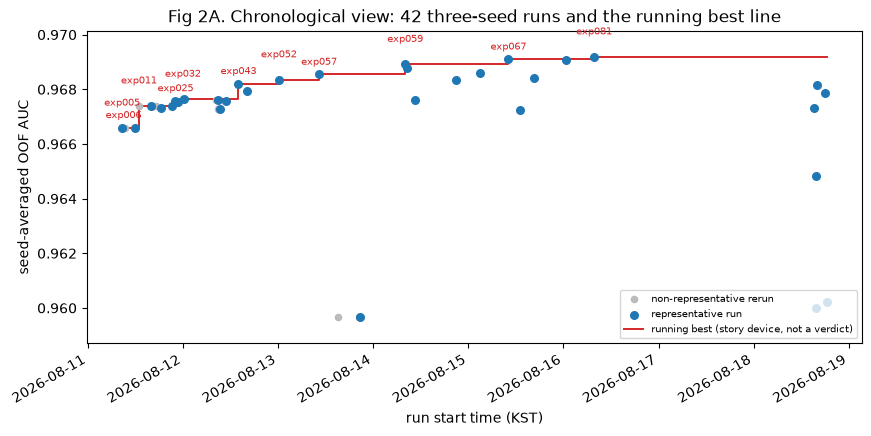

시간순 최고선을 갱신한 구성(순서대로): exp005_te_replacement -> exp006_te_drop_gaming -> exp011_resid_pair -> exp025_constrained_impute -> exp032_recon_orig_mean_top3 -> exp043_cat_depth6 -> exp052_cat_xgb_impute_pass5 -> exp057_cat_xgb_impute_comps5 -> exp059_lookup_transformer -> exp067_lookup_xgb_impute_comps5 -> exp081_lookup_fold_initialization_avg3


In [9]:
import matplotlib.pyplot as plt

# 그림 2A: P1 42건 시간순 산점도 + 시간순 최고선
timeline = p1.sort_values("start")
running_best = timeline["auc_oof"].cummax()
is_rep = timeline.index.isin(p3.index)

fig, ax = plt.subplots(figsize=(10, 4.6))
ax.scatter(timeline.loc[~is_rep, "start"], timeline.loc[~is_rep, "auc_oof"], s=20, c="#bbbbbb",
           label="non-representative rerun", zorder=2)
ax.scatter(timeline.loc[is_rep, "start"], timeline.loc[is_rep, "auc_oof"], s=30, c="#1f77b4",
           label="representative run", zorder=3)
ax.step(timeline["start"], running_best, where="post", c="#d62728", lw=1.4,
        label="running best (story device, not a verdict)", zorder=1)

best_line_configs = []
_best = float("-inf")
for _rid, _row in timeline.iterrows():
    if _row["auc_oof"] > _best + 1e-12:
        _best = _row["auc_oof"]
        best_line_configs.append(_row["config"])
        _lift = 7 + 9 * (len(best_line_configs) % 2)
        ax.annotate(_row["short"], (_row["start"], _row["auc_oof"]), textcoords="offset points",
                    xytext=(0, _lift), fontsize=7, ha="center", color="#d62728")
ax.margins(y=0.1)

ax.set_xlabel("run start time (KST)")
ax.set_ylabel("seed-averaged OOF AUC")
ax.set_title("Fig 2A. Chronological view: 42 three-seed runs and the running best line")
ax.legend(fontsize=7, loc="lower right")
fig.autofmt_xdate()
plt.show()

print("시간순 최고선을 갱신한 구성(순서대로):", " -> ".join(best_line_configs))

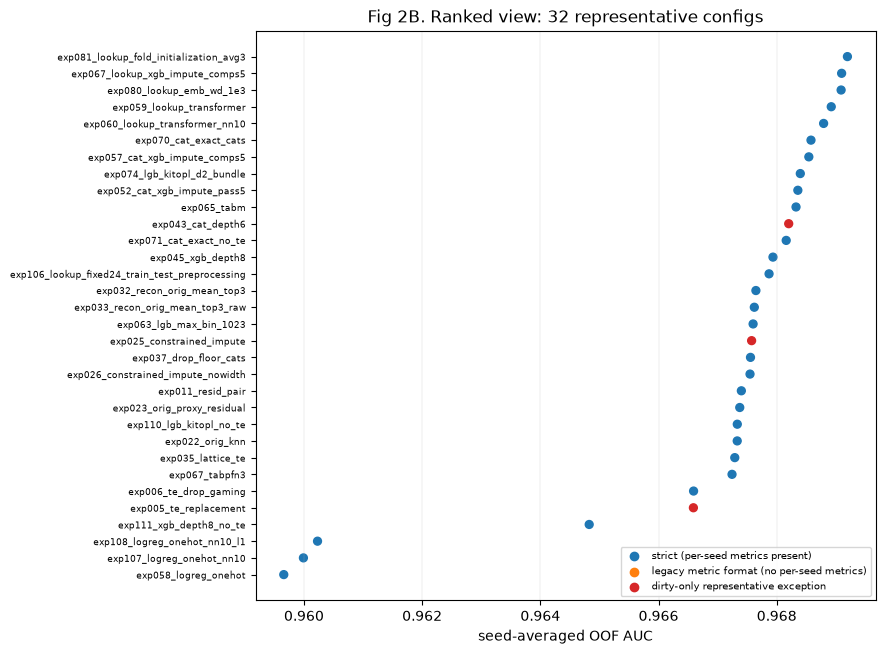

In [10]:
# 그림 2B: 대표 32건의 순위 점 그림
ranked = p3.sort_values("auc_oof")
_colors = [
    "#d62728" if row["dirty_rep_exception"] else ("#ff7f0e" if not row["strict"] else "#1f77b4")
    for _, row in ranked.iterrows()
]
fig, ax = plt.subplots(figsize=(8, 7.4))
ax.scatter(ranked["auc_oof"], range(len(ranked)), c=_colors, s=32)
ax.scatter([], [], c="#1f77b4", label="strict (per-seed metrics present)")
ax.scatter([], [], c="#ff7f0e", label="legacy metric format (no per-seed metrics)")
ax.scatter([], [], c="#d62728", label="dirty-only representative exception")
ax.set_yticks(range(len(ranked)))
ax.set_yticklabels(ranked["config"], fontsize=6.5)
ax.set_xlabel("seed-averaged OOF AUC")
ax.set_title("Fig 2B. Ranked view: 32 representative configs")
ax.grid(axis="x", lw=0.3, alpha=0.5)
ax.legend(fontsize=7, loc="lower right")
plt.show()

champion 계보의 시간 흐름은 다음과 같이 요약된다.
8월 11일의 목표 인코딩 계열(exp005, exp006)에서 출발해 잔차 쌍 특성(exp011), 제약 결측 대치(exp025), 재구성 특성(exp032)으로 특성 실험이 이어졌고, 8월 12일부터 CatBoost 계열(exp043, exp052, exp057)이 최고선을 끌어올렸다.
8월 14일 이후에는 lookup Transformer 계열(exp059, exp067, exp081)이 최고선을 이어받아, 동결 시점 champion은 exp081_lookup_fold_initialization_avg3(OOF 0.96920)다.
그림 2B의 순위 지형에서도 상위권은 lookup Transformer와 CatBoost 계열이 차지하고, 선형 모델 계열(logreg)은 다양성 목적으로만 남아 있다.

## §3 시드 안정성 (엄격 39건)

시드별 OOF metric을 모두 가진 엄격 39건으로 시드 잡음의 크기를 재고, ADR 0001의 판정 눈금(동률 0.00002, 실질 0.0002)이 실측 분포와 정합하는지 검증한다.

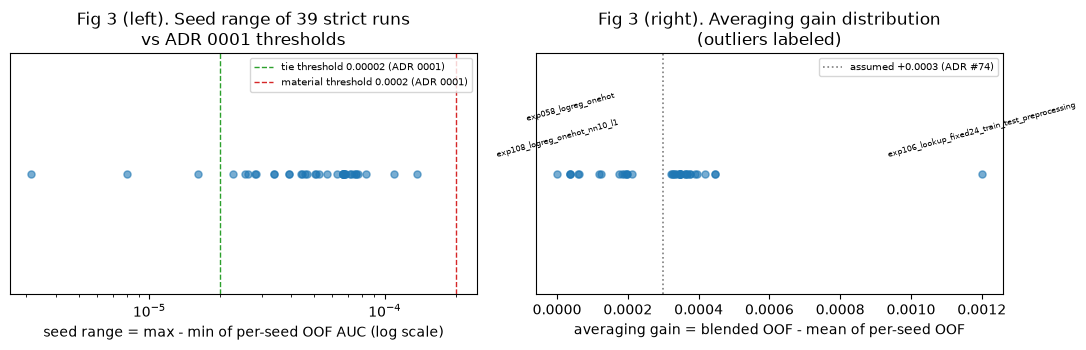

In [11]:
strict_runs = p2

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].scatter(strict_runs["seed_range"], [0.5] * len(strict_runs), s=26, alpha=0.6, c="#1f77b4")
axes[0].axvline(0.00002, c="#2ca02c", ls="--", lw=1, label="tie threshold 0.00002 (ADR 0001)")
axes[0].axvline(0.0002, c="#d62728", ls="--", lw=1, label="material threshold 0.0002 (ADR 0001)")
axes[0].set_xscale("log")
axes[0].set_yticks([])
axes[0].set_xlabel("seed range = max - min of per-seed OOF AUC (log scale)")
axes[0].set_title("Fig 3 (left). Seed range of 39 strict runs\nvs ADR 0001 thresholds")
axes[0].legend(fontsize=7)

axes[1].scatter(strict_runs["avg_gain"], [0.5] * len(strict_runs), s=26, alpha=0.6, c="#1f77b4")
axes[1].axvline(0.0003, c="#7f7f7f", ls=":", lw=1.2, label="assumed +0.0003 (ADR #74)")
_outlier_index = 0
_labeled_configs = set()
for _, _row in strict_runs.sort_values("avg_gain").iterrows():
    _is_outlier = _row["avg_gain"] > 0.0008 or _row["avg_gain"] < 0.00005
    if _is_outlier and _row["config"] not in _labeled_configs:
        _labeled_configs.add(_row["config"])
        _lift = 12 + 26 * (_outlier_index % 2)
        _outlier_index += 1
        axes[1].annotate(_row["config"], (_row["avg_gain"], 0.5), textcoords="offset points",
                         xytext=(0, _lift), fontsize=6, ha="center", rotation=15)
axes[1].margins(y=0.35)
axes[1].set_yticks([])
axes[1].set_xlabel("averaging gain = blended OOF - mean of per-seed OOF")
axes[1].set_title("Fig 3 (right). Averaging gain distribution\n(outliers labeled)")
axes[1].legend(fontsize=7)
plt.tight_layout()
plt.show()

In [12]:
seed_stats_table = pd.DataFrame(
    [
        ("시드 범위 중앙값", f"{strict_runs['seed_range'].median():.6f}", "0.000057"),
        ("시드 범위 p90", f"{strict_runs['seed_range'].quantile(0.9):.6f}", "0.000076"),
        ("시드 범위 최댓값", f"{strict_runs['seed_range'].max():.6f}", "0.000137"),
        ("평균화 이득 중앙값", f"{strict_runs['avg_gain'].median():+.6f}", "+0.000334"),
    ],
    columns=["지표", "실측", "동결 기대값(참고)"],
)
display(seed_stats_table)
print(f"시드 범위가 0.0002 이상인 실행 수: {int((strict_runs['seed_range'] >= 0.0002).sum())} (동결 기대값 0)")

legacy_table = p1.loc[~p1["strict"], ["config", "start", "auc_oof"]].copy()
legacy_table["참여 불가 사유"] = "LEGACY_FORMAT: 시드별 OOF metric이 없어 시드 안정성 분석에 참여하지 못함"
legacy_table.index = [rid[:8] for rid in legacy_table.index]
display(legacy_table)

,지표,실측,동결 기대값(참고)
0,시드 범위 중앙값,0.000057,0.000057
1,시드 범위 p90,0.000076,0.000076
2,시드 범위 최댓값,0.000137,0.000137
3,평균화 이득 중앙값,+0.000334,+0.000334


시드 범위가 0.0002 이상인 실행 수: 0 (동결 기대값 0)


,config,start,auc_oof,참여 불가 사유
f4e77ff3,exp005_te_replacement,2026-08-11 08:36:03.722000+09:00,0.966589,LEGACY_FORMAT: 시드별 OOF metric이 없어 시드 안정성 분석에 참여하지 못함
01a466bd,exp006_te_drop_gaming,2026-08-11 08:57:37.943000+09:00,0.966592,LEGACY_FORMAT: 시드별 OOF metric이 없어 시드 안정성 분석에 참여하지 못함
264f7e6f,exp006_te_drop_gaming,2026-08-11 09:25:28.325000+09:00,0.966592,LEGACY_FORMAT: 시드별 OOF metric이 없어 시드 안정성 분석에 참여하지 못함


In [13]:
# 경계 구간 쌍의 같은 시드 승수: 우열을 실제로 주장하는 쌍에서만 계산한다.
# 대상은 P3 인접 순위 쌍과 champion 계보 교체 쌍이고, 대표 32건의 전 쌍에는 적용하지 않는다.
def adr_band(delta):
    if delta < 0.00002:
        return "동률"
    if delta < 0.0002:
        return "경계"
    return "실질"


def same_seed_wins(higher, lower):
    if not (higher["strict"] and lower["strict"]):
        return "지표 없음"
    wins = sum(int(higher[m] > lower[m]) for m in SEED_METRICS)
    return f"{wins}/3"


pair_rows = {}
ranked_desc = p3.sort_values("auc_oof", ascending=False)
for i in range(len(ranked_desc) - 1):
    upper, lower = ranked_desc.iloc[i], ranked_desc.iloc[i + 1]
    _key = (upper["config"], lower["config"])
    pair_rows[_key] = {"types": ["인접 순위"], "upper": upper, "lower": lower}

rep_by_config = p3.set_index("config")
for prev_cfg, next_cfg in zip(best_line_configs[:-1], best_line_configs[1:]):
    upper, lower = rep_by_config.loc[next_cfg], rep_by_config.loc[prev_cfg]
    _key = (next_cfg, prev_cfg)
    if _key in pair_rows:
        pair_rows[_key]["types"].append("champion 교체")
    else:
        pair_rows[_key] = {"types": ["champion 교체"], "upper": upper, "lower": lower}

border_pair_table = pd.DataFrame(
    [
        {
            "쌍 유형": " + ".join(entry["types"]),
            "상위 구성": entry["upper"]["config"] if "config" in entry["upper"] else entry["upper"].name,
            "하위 구성": entry["lower"]["config"] if "config" in entry["lower"] else entry["lower"].name,
            "Δ OOF": round(float(entry["upper"]["auc_oof"] - entry["lower"]["auc_oof"]), 6),
            "같은 시드 승수": same_seed_wins(entry["upper"], entry["lower"]),
        }
        for entry in pair_rows.values()
        if adr_band(float(entry["upper"]["auc_oof"] - entry["lower"]["auc_oof"])) == "경계"
    ]
).sort_values("Δ OOF", ascending=False, ignore_index=True)
display(border_pair_table)

,쌍 유형,상위 구성,하위 구성,Δ OOF,같은 시드 승수
0,champion 교체,exp057_cat_xgb_impute_comps5,exp052_cat_xgb_impute_pass5,0.000186,3/3
1,champion 교체,exp067_lookup_xgb_impute_comps5,exp059_lookup_transformer,0.000176,3/3
2,champion 교체,exp025_constrained_impute,exp011_resid_pair,0.000174,3/3
3,인접 순위,exp080_lookup_emb_wd_1e3,exp059_lookup_transformer,0.000167,3/3
4,champion 교체,exp052_cat_xgb_impute_pass5,exp043_cat_depth6,0.000155,3/3
5,인접 순위,exp026_constrained_impute_nowidth,exp011_resid_pair,0.000147,3/3
6,인접 순위,exp057_cat_xgb_impute_comps5,exp074_lgb_kitopl_d2_bundle,0.000144,3/3
7,인접 순위,exp059_lookup_transformer,exp060_lookup_transformer_nn10,0.000129,3/3
8,인접 순위,exp065_tabm,exp043_cat_depth6,0.000124,3/3
9,인접 순위 + champion 교체,exp081_lookup_fold_initialization_avg3,exp067_lookup_xgb_impute_comps5,0.000098,3/3


실측 시드 잡음은 ADR 0001의 눈금과 정합한다.
엄격 39건의 시드 범위는 전부 실질 문턱 0.0002 아래에 있고(0건 초과), 중앙값 0.000057은 동률 문턱 0.00002와 실질 문턱 사이의 경계 구간에 놓인다.
따라서 동률(< 0.00002) 판정은 시드 잡음보다 작은 차이를 우열로 읽지 않겠다는 뜻으로, 실질(≥ 0.0002) 판정은 관측된 최대 시드 잡음 0.000137보다 큰 차이만 실질로 읽겠다는 뜻으로 실측과 맞는다.
경계 구간의 우열 주장은 위 표의 같은 시드 승수로 보강한다.
같은 시드 승수가 3/3인 쌍은 시드 잡음을 통제해도 우열이 유지되는 반면, 0/3이나 1/3인 쌍은 시드 평균본의 우위가 시드별 비교에서 뒤집혀 경계 구간 판정의 주의 사례로 남는다.

## §4 전이 분석 (10건)

> 이 표본은 유망 실행만 선택적으로 제출된 10건이며, 모든 결론은 이 표본 안의 관찰 서술이다. 미제출 실행이나 미래 실행으로 일반화하지 않는다.

In [14]:
from itertools import combinations

transfer_sorted = transfer_runs.sort_values("auc_oof")
gap = transfer_sorted["public_auc"] - transfer_sorted["auc_oof"]

inversion_run_ids = set()
_n_pairs = 0
for (rid_a, row_a), (rid_b, row_b) in combinations(transfer_sorted.iterrows(), 2):
    _n_pairs += 1
    if (row_a["auc_oof"] - row_b["auc_oof"]) * (row_a["public_auc"] - row_b["public_auc"]) < 0:
        inversion_run_ids.update((rid_a, rid_b))
n_inversions = sum(
    1
    for (rid_a, row_a), (rid_b, row_b) in combinations(transfer_sorted.iterrows(), 2)
    if (row_a["auc_oof"] - row_b["auc_oof"]) * (row_a["public_auc"] - row_b["public_auc"]) < 0
)
kendall_tau = transfer_sorted[["auc_oof", "public_auc"]].corr(method="kendall").iloc[0, 1]

transfer_stats_table = pd.DataFrame(
    [
        ("역전 쌍 수", f"{n_inversions} / {_n_pairs}쌍", "0 / 45쌍"),
        ("Kendall τ (p값 없음)", f"{kendall_tau:.2f}", "1.00"),
        ("격차(Public - OOF) 중앙값", f"{gap.median():+.5f}", "약 +0.00125"),
        ("격차 범위", f"{gap.min():+.5f} ~ {gap.max():+.5f}", "+0.00113 ~ +0.00143"),
    ],
    columns=["지표", "실측", "동결 기대값(참고)"],
)
display(transfer_stats_table)

,지표,실측,동결 기대값(참고)
0,역전 쌍 수,0 / 45쌍,0 / 45쌍
1,Kendall τ (p값 없음),1.00,1.00
2,격차(Public - OOF) 중앙값,+0.00124,약 +0.00125
3,격차 범위,+0.00113 ~ +0.00143,+0.00113 ~ +0.00143


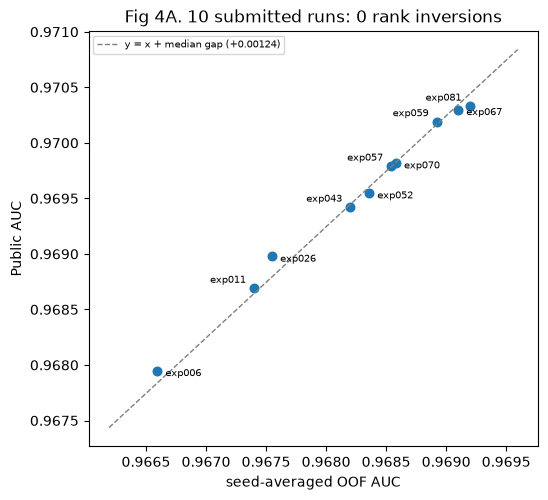

In [15]:
# 그림 4A: OOF 대 Public 산점도
fig, ax = plt.subplots(figsize=(5.8, 5.4))
ax.scatter(transfer_sorted["auc_oof"], transfer_sorted["public_auc"], s=38, c="#1f77b4")
_lims = [transfer_sorted["auc_oof"].min() - 0.0004, transfer_sorted["auc_oof"].max() + 0.0004]
ax.plot(_lims, [v + gap.median() for v in _lims], c="#7f7f7f", ls="--", lw=1,
        label=f"y = x + median gap ({gap.median():+.5f})")
for _rank, (_, _row) in enumerate(transfer_sorted.iterrows()):
    _right_side = _rank % 2 == 0
    ax.annotate(_row["short"], (_row["auc_oof"], _row["public_auc"]), textcoords="offset points",
                xytext=(6, -4) if _right_side else (-6, 4), fontsize=7,
                ha="left" if _right_side else "right")
ax.set_xlabel("seed-averaged OOF AUC")
ax.set_ylabel("Public AUC")
ax.set_title(f"Fig 4A. 10 submitted runs: {n_inversions} rank inversions")
ax.legend(fontsize=7)
plt.show()

In [16]:
# 시간순 증분 표: 제출 실행을 시작 시각 순으로 놓고 인접 쌍의 증분을 서술한다.
chrono = transfer_runs.sort_values("start")[["config", "start", "auc_oof", "public_auc"]].copy()
chrono["ΔOOF"] = chrono["auc_oof"].diff()
chrono["ΔPublic"] = chrono["public_auc"].diff()
chrono["방향 일치"] = [
    "-" if pd.isna(do) else ("같음" if do * dp > 0 else ("둘 다 0" if do == dp == 0 else "다름"))
    for do, dp in zip(chrono["ΔOOF"], chrono["ΔPublic"])
]
chrono.index = [rid[:8] for rid in chrono.index]
chrono["start"] = chrono["start"].dt.strftime("%m-%d %H:%M")
for _col in ["auc_oof", "public_auc", "ΔOOF", "ΔPublic"]:
    chrono[_col] = chrono[_col].round(5)
display(chrono)

,config,start,auc_oof,public_auc,ΔOOF,ΔPublic,방향 일치
264f7e6f,exp006_te_drop_gaming,08-11 09:25,0.96659,0.96795,NaN,NaN,-
e21d19af,exp011_resid_pair,08-11 12:50,0.96740,0.96869,0.00081,0.00074,같음
62f57ea7,exp026_constrained_impute_nowidth,08-11 22:36,0.96755,0.96898,0.00015,0.00029,같음
737f4dae,exp043_cat_depth6,08-12 13:58,0.96820,0.96942,0.00065,0.00044,같음
2c615036,exp052_cat_xgb_impute_pass5,08-13 00:09,0.96836,0.96955,0.00015,0.00013,같음
3d5239b0,exp057_cat_xgb_impute_comps5,08-13 10:18,0.96854,0.96979,0.00019,0.00024,같음
b951fac5,exp059_lookup_transformer,08-14 08:02,0.96892,0.97019,0.00038,0.00040,같음
6238d8c5,exp070_cat_exact_cats,08-15 03:03,0.96858,0.96982,-0.00034,-0.00037,같음
2bd55026,exp067_lookup_xgb_impute_comps5,08-15 10:05,0.96910,0.97030,0.00052,0.00048,같음
d55d1cd4,exp081_lookup_fold_initialization_avg3,08-16 07:43,0.96920,0.97033,0.00010,0.00003,같음


제출된 실행들에서 OOF 개선과 Public 개선이 같은 방향이었다(관찰 표본 한정).

이 10건은 무작위 표본이 아니라 선택된 표본이다.
아래 그림 4B는 제출 10건이 P1 42건의 OOF 분포에서 어디에 놓이는지 보인다.

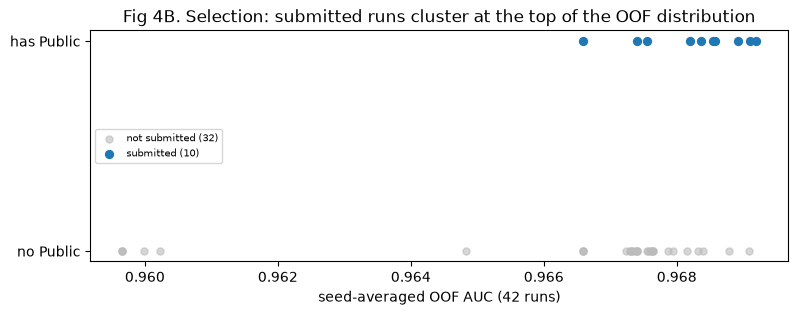

제출 표본의 OOF 분위수: 최소 0.96659, 1분위 0.96771, 중앙값 0.96845, 3분위 0.96884, 최대 0.96920


In [17]:
# 그림 4B: 제출 10건과 미제출 32건의 OOF 분포 비교
submitted_mask = p1.index.isin(transfer_runs.index)
fig, ax = plt.subplots(figsize=(9, 3.0))
ax.scatter(p1.loc[~submitted_mask, "auc_oof"], [0] * int((~submitted_mask).sum()), s=26, alpha=0.6,
           c="#bbbbbb", label=f"not submitted ({int((~submitted_mask).sum())})")
ax.scatter(p1.loc[submitted_mask, "auc_oof"], [1] * int(submitted_mask.sum()), s=32,
           c="#1f77b4", label=f"submitted ({int(submitted_mask.sum())})")
ax.set_yticks([0, 1])
ax.set_yticklabels(["no Public", "has Public"])
ax.set_xlabel("seed-averaged OOF AUC (42 runs)")
ax.set_title("Fig 4B. Selection: submitted runs cluster at the top of the OOF distribution")
ax.legend(fontsize=7, loc="center left")
plt.show()

_q = transfer_runs["auc_oof"].quantile([0, 0.25, 0.5, 0.75, 1.0])
print(
    "제출 표본의 OOF 분위수: "
    f"최소 {_q[0]:.5f}, 1분위 {_q[0.25]:.5f}, 중앙값 {_q[0.5]:.5f}, 3분위 {_q[0.75]:.5f}, 최대 {_q[1.0]:.5f}"
)

In [18]:
print("제출 선택 규칙은 통계 모형이 아니라 사람의 판단이었다: champion 계보의 유망 실행만 골라 제출했다.")
_exp001 = p0[(p0["experiment"] == "exp001_lgbm_baseline") & p0["public_auc"].notna()].iloc[0]
print(
    f"각주: 단일 시드 exp001_lgbm_baseline(run {_exp001.name[:8]})은 Public {_exp001['public_auc']:.5f}를 보유하나 "
    "3시드 모집단 밖이라 그림과 분석에서 제외한다."
)
_full_refit = p0[p0["status"].eq("FINISHED") & p0["auc_oof"].isna()].iloc[0]
print(
    f"각주: full refit 제출 {_full_refit.name[:8]}(NO_OOF)은 Public {_full_refit['public_auc']:.5f}의 존재만 확인한다. "
    "앙상블 전이는 §5에서 다룬다."
)

제출 선택 규칙은 통계 모형이 아니라 사람의 판단이었다: champion 계보의 유망 실행만 골라 제출했다.
각주: 단일 시드 exp001_lgbm_baseline(run ce66e16b)은 Public 0.96450를 보유하나 3시드 모집단 밖이라 그림과 분석에서 제외한다.
각주: full refit 제출 c2171fa9(NO_OOF)은 Public 0.97063의 존재만 확인한다. 앙상블 전이는 §5에서 다룬다.


## §5 앙상블 구획 (7건)

앙상블 실행의 `auc_oof`는 nested OOF라 단일 모델의 시드 평균본 OOF와 산출 방식이 다르고, 시드 안정성 분석은 적용할 수 없다.

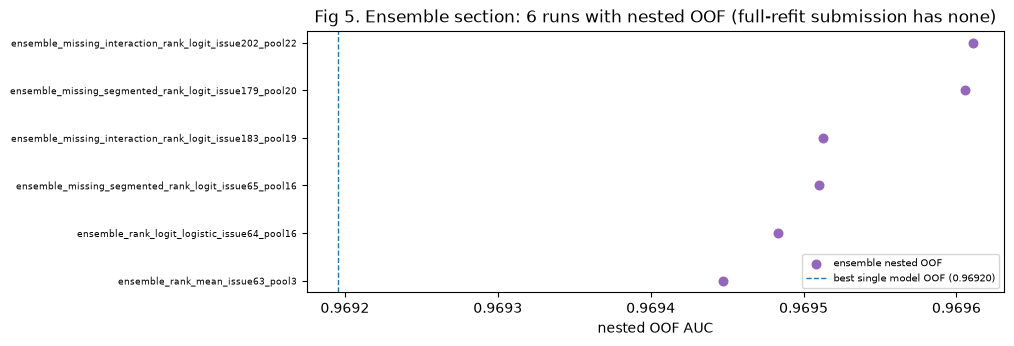

In [19]:
# 그림 5: nested OOF를 가진 앙상블 6건의 점 그림
ensembles_with_oof = ensemble_runs[ensemble_runs["auc_oof"].notna()].sort_values("auc_oof")
best_single_oof = p3["auc_oof"].max()
fig, ax = plt.subplots(figsize=(9, 3.4))
ax.scatter(ensembles_with_oof["auc_oof"], range(len(ensembles_with_oof)), c="#9467bd", s=38,
           label="ensemble nested OOF")
ax.axvline(best_single_oof, c="#1f77b4", ls="--", lw=1,
           label=f"best single model OOF ({best_single_oof:.5f})")
ax.set_yticks(range(len(ensembles_with_oof)))
ax.set_yticklabels(ensembles_with_oof["run_name"], fontsize=6.5)
ax.set_xlabel("nested OOF AUC")
ax.set_title("Fig 5. Ensemble section: 6 runs with nested OOF (full-refit submission has none)")
ax.legend(fontsize=7, loc="lower right")
plt.show()

In [20]:
# Public을 가진 앙상블 3건(OOF 짝 보유)의 전이: §4와 같은 방식의 서술 통계만 싣는다.
ens_transfer = ensembles_with_oof[ensembles_with_oof["public_auc"].notna()].sort_values("auc_oof")
ens_gap = ens_transfer["public_auc"] - ens_transfer["auc_oof"]
_ens_inversions = sum(
    1
    for (_, a), (_, b) in combinations(ens_transfer.iterrows(), 2)
    if (a["auc_oof"] - b["auc_oof"]) * (a["public_auc"] - b["public_auc"]) < 0
)
ens_transfer_table = ens_transfer[["run_name", "auc_oof", "public_auc"]].copy()
ens_transfer_table["격차(Public-OOF)"] = ens_gap
ens_transfer_table.index = [rid[:8] for rid in ens_transfer_table.index]
display(ens_transfer_table.round(5))
print(f"앙상블 전이 서술 통계: 역전 {_ens_inversions}/{len(ens_transfer) * (len(ens_transfer) - 1) // 2}쌍, "
      f"격차 중앙값 {ens_gap.median():+.5f} (관찰 표본 한정)")

_full_refit = ensemble_runs[ensemble_runs["auc_oof"].isna()].iloc[0]
print(f"full refit 제출 {_full_refit.name[:8]}는 Public {_full_refit['public_auc']:.5f}의 존재만 확인한다.")

_untagged = ensemble_runs[~ensemble_runs["has_git_commit_tag"]]
print(
    f"기록 격차: 앙상블 {len(_untagged)}건({', '.join(rid[:8] for rid in _untagged.sort_values('start').index)})에 "
    "git_commit·git_dirty 태그가 없어, 앙상블 구획에서는 커밋 기반 판별을 쓰지 않는다."
)

,run_name,auc_oof,public_auc,격차(Public-OOF)
1a1a6b42,ensemble_rank_mean_issue63_pool3,0.96945,0.97055,0.00110
d7c53c28,ensemble_rank_logit_logistic_issue64_pool16,0.96948,0.97056,0.00108
455c5aad,ensemble_missing_segmented_rank_logit_issue65_pool16,0.96951,0.97057,0.00106


앙상블 전이 서술 통계: 역전 0/3쌍, 격차 중앙값 +0.00108 (관찰 표본 한정)
full refit 제출 c2171fa9는 Public 0.97063의 존재만 확인한다.
기록 격차: 앙상블 3건(d845b5d1, 7fbe590b, 86d87d91)에 git_commit·git_dirty 태그가 없어, 앙상블 구획에서는 커밋 기반 판별을 쓰지 않는다.


## §6 민감도 분석 (P3 32 vs P1 42)

대표 1건을 고르는 선택이 결론을 바꾸는지 세 가지 검사로 확인한다.
새 그림과 새 지표 없이 결론 차이만 한 표로 보고한다.

In [21]:
# 검사 1: 대표와 비대표 재실행의 OOF 차이가 P3 순위를 바꾸는가.
alternatives_by_config = {
    cfg: group["auc_oof"].tolist() for cfg, group in p1.groupby("config") if len(group) > 1
}
baseline_order = p3.sort_values("auc_oof", ascending=False)["config"].tolist()
rep_oof_by_config = p3.set_index("config")["auc_oof"].to_dict()
max_rerun_spread = 0.0
rank_changed = False
for cfg, values in alternatives_by_config.items():
    for value in values:
        max_rerun_spread = max(max_rerun_spread, abs(value - rep_oof_by_config[cfg]))
        _swapped = dict(rep_oof_by_config)
        _swapped[cfg] = value
        if sorted(_swapped, key=_swapped.get, reverse=True) != baseline_order:
            rank_changed = True

# 검사 2: 시간순 최고선 모양이 P1 42건과 P3 32건에서 다른가.
def running_best_configs(frame):
    result, best = [], float("-inf")
    for _, row in frame.sort_values("start").iterrows():
        if row["auc_oof"] > best + 1e-12:
            best = row["auc_oof"]
            result.append(row["config"])
    return result

lineage_p1 = running_best_configs(p1)
lineage_p3 = running_best_configs(p3)

# 검사 3: 인접 순위 쌍 31개의 ADR 3구간 분류가 대표 대신 다른 실행 값을 쓰면 달라지는가.
band_changed_pairs = []
for i in range(len(baseline_order) - 1):
    cfg_upper, cfg_lower = baseline_order[i], baseline_order[i + 1]
    base_band = adr_band(rep_oof_by_config[cfg_upper] - rep_oof_by_config[cfg_lower])
    for upper_value in alternatives_by_config.get(cfg_upper, [rep_oof_by_config[cfg_upper]]):
        for lower_value in alternatives_by_config.get(cfg_lower, [rep_oof_by_config[cfg_lower]]):
            if adr_band(upper_value - lower_value) != base_band:
                band_changed_pairs.append((cfg_upper, cfg_lower))

sensitivity_table = pd.DataFrame(
    [
        ("순위 역전", "구성별 대표-비대표 OOF 차이로 P3 순위 재계산",
         "있음" if rank_changed else "없음", f"재실행 간 최대 OOF 차이 {max_rerun_spread:.2e}"),
        ("시간순 최고선 모양", "P1 42건과 P3 32건의 최고선 갱신 구성 목록 비교",
         "있음" if lineage_p1 != lineage_p3 else "없음",
         f"갱신 구성 {len(lineage_p1)}개가 양쪽에서 동일"),
        ("동률·경계 판정", "인접 순위 쌍 31개의 ADR 3구간 분류를 재실행 값으로 재계산",
         "있음" if band_changed_pairs else "없음",
         "달라지는 쌍 없음" if not band_changed_pairs else f"달라지는 쌍: {band_changed_pairs}"),
    ],
    columns=["검사", "방법", "결론 차이", "비고"],
)
display(sensitivity_table)
if not (rank_changed or lineage_p1 != lineage_p3 or band_changed_pairs):
    print("대표 선정이 결론을 바꾸지 않음.")
else:
    print("주의: 위 표에서 차이가 있는 행은 표본 선택 편향으로 표시한다.")

,검사,방법,결론 차이,비고
0,순위 역전,구성별 대표-비대표 OOF 차이로 P3 순위 재계산,없음,재실행 간 최대 OOF 차이 1.93e-10
1,시간순 최고선 모양,P1 42건과 P3 32건의 최고선 갱신 구성 목록 비교,없음,갱신 구성 11개가 양쪽에서 동일
2,동률·경계 판정,인접 순위 쌍 31개의 ADR 3구간 분류를 재실행 값으로 재계산,없음,달라지는 쌍 없음


대표 선정이 결론을 바꾸지 않음.


## §7 다음 실험 권고 표

ADR 0001과의 경계는 다음 세 문장으로 고정한다.

- 다음 실험 권고는 채택 판정이 아니며 champion·풀 장부를 변경하지 않는다.
- 권고는 전이 표시를 쓸 수 있지만, 채택 판정은 여전히 Public을 쓰지 못한다.
- 권고 규칙이 ADR 0001의 문턱 숫자를 빌리거나 새 상수를 두더라도 그 의미는 다음 실험 우선순위로 한정된다.

§4의 고정 경고문은 이 구획의 전이 표시에도 그대로 계승된다.

> 이 표본은 유망 실행만 선택적으로 제출된 10건이며, 모든 결론은 이 표본 안의 관찰 서술이다. 미제출 실행이나 미래 실행으로 일반화하지 않는다.

다양성 소관은 다음 문장으로 위임한다.

- 다양성 목적 변형 실험의 우선순위는 단일 모델 행이 아니라 앙상블 대표 행의 확장(풀 확충)에 싣는다.

권고 규칙(#213): 확장 후보권은 시드 평균본 OOF AUC ≥ champion `oof_auc` − 0.001이고, 증거 결함은 LEGACY_FORMAT, dirty 대표 예외, 시드 범위 ≥ 0.0002 중 하나 이상이다.
규칙 1 후보권이고 결함 있음 → 재검증, 규칙 2 후보권이고 결함 없음 → 확장, 규칙 3 후보권 밖이고 풀 장부 구성원 → 보류, 규칙 4 그 외 → 중단을 첫 일치로 적용한다.
앙상블 대표 행은 nested OOF가 champion 시드 평균본 OOF 대비 +0.00002 이상이면 확장, 미만이면 보류다.

In [22]:
CANDIDATE_THRESHOLD = champion_oof - 0.001
GRADE_ORDER = {"확장": 0, "재검증": 1, "보류": 2, "중단": 3}


def transfer_mark(config):
    submitted = transfer_runs[transfer_runs["config"] == config]
    if not len(submitted):
        return "미제출"
    if set(submitted.index) & inversion_run_ids:
        return "역전 관찰"
    return "전이 일치"


recommendation_rows = []
for run_id, rep in p3.iterrows():
    defects = []
    if not rep["strict"]:
        defects.append("LEGACY_FORMAT")
    if rep["dirty_rep_exception"]:
        defects.append("dirty 대표 예외")
    if rep["strict"] and rep["seed_range"] >= 0.0002:
        defects.append("시드 범위 0.0002 이상")
    in_candidate_zone = rep["auc_oof"] >= CANDIDATE_THRESHOLD
    mark = transfer_mark(rep["config"])
    if in_candidate_zone and defects:
        grade, rule_name = "재검증", "규칙 1(후보권·결함 있음)"
    elif in_candidate_zone:
        grade, rule_name = "확장", "규칙 2(후보권·결함 없음)"
    elif rep["config"] in pool_member_configs:
        grade, rule_name = "보류", "규칙 3(후보권 밖 풀 구성원)"
    else:
        grade, rule_name = "중단", "규칙 4(그 외)"
    recommendation_rows.append(
        {
            "구성": rep["config"],
            "OOF": rep["auc_oof"],
            "시드 안정성": f"{rep['seed_range']:.6f}" if rep["strict"] else "지표 없음",
            "전이 표시": mark,
            "근거 요약": f"{rule_name}; OOF {rep['auc_oof']:.5f}; 결함 {', '.join(defects) if defects else '없음'}; {mark}",
            "권고": grade,
            "_candidate": in_candidate_zone,
            "_series": rep["series"],
            "_start": rep["start"],
        }
    )

ensemble_rep = ensemble_runs[ensemble_runs["auc_oof"].notna()].sort_values("start").iloc[-1]
_ens_delta = ensemble_rep["auc_oof"] - champion_oof
_ens_grade = "확장" if _ens_delta >= 0.00002 else "보류"
_ens_mark = "미제출" if pd.isna(ensemble_rep["public_auc"]) else transfer_mark(ensemble_rep["config"])
recommendation_rows.append(
    {
        "구성": ensemble_rep["run_name"],
        "OOF": ensemble_rep["auc_oof"],
        "시드 안정성": "적용 불가",
        "전이 표시": _ens_mark,
        "근거 요약": (
            f"앙상블 규칙(champion 대비 +0.00002 이상이면 확장); OOF {ensemble_rep['auc_oof']:.5f}; "
            f"champion 대비 {_ens_delta:+.5f}; {_ens_mark}"
        ),
        "권고": _ens_grade,
        "_candidate": False,
        "_series": ensemble_rep["series"],
        "_start": ensemble_rep["start"],
    }
)

recommendation_table = pd.DataFrame(recommendation_rows)
recommendation_table["_grade_order"] = recommendation_table["권고"].map(GRADE_ORDER)
recommendation_table["_transfer_order"] = (recommendation_table["전이 표시"] != "전이 일치").astype(int)
recommendation_table.loc[recommendation_table["_grade_order"] != 0, "_transfer_order"] = 0
recommendation_table = recommendation_table.sort_values(
    ["_grade_order", "_transfer_order", "OOF"], ascending=[True, True, False], ignore_index=True
)
n_candidate_zone = int(recommendation_table["_candidate"].sum())
_display = recommendation_table[["구성", "OOF", "시드 안정성", "전이 표시", "근거 요약", "권고"]].copy()
_display["OOF"] = _display["OOF"].map(lambda v: f"{v:.5f}")
display(_display)
print(f"확장 후보권 구성 수: {n_candidate_zone}")
print("권고 분포:", recommendation_table["권고"].value_counts().to_dict())

,구성,OOF,시드 안정성,전이 표시,근거 요약,권고
0,exp081_lookup_fold_initialization_avg3,0.96920,0.000034,전이 일치,규칙 2(후보권·결함 없음); OOF 0.96920; 결함 없음; 전이 일치,확장
1,exp067_lookup_xgb_impute_comps5,0.96910,0.000016,전이 일치,규칙 2(후보권·결함 없음); OOF 0.96910; 결함 없음; 전이 일치,확장
2,exp059_lookup_transformer,0.96892,0.000051,전이 일치,규칙 2(후보권·결함 없음); OOF 0.96892; 결함 없음; 전이 일치,확장
3,exp070_cat_exact_cats,0.96858,0.000028,전이 일치,규칙 2(후보권·결함 없음); OOF 0.96858; 결함 없음; 전이 일치,확장
4,exp057_cat_xgb_impute_comps5,0.96854,0.000053,전이 일치,규칙 2(후보권·결함 없음); OOF 0.96854; 결함 없음; 전이 일치,확장
5,exp052_cat_xgb_impute_pass5,0.96836,0.000026,전이 일치,규칙 2(후보권·결함 없음); OOF 0.96836; 결함 없음; 전이 일치,확장
6,ensemble_missing_interaction_rank_logit_issue202_pool22,0.96961,적용 불가,미제출,앙상블 규칙(champion 대비 +0.00002 이상이면 확장); OOF 0.96961; champion 대비 +0.00041; 미제출,확장
7,exp080_lookup_emb_wd_1e3,0.96909,0.000008,미제출,규칙 2(후보권·결함 없음); OOF 0.96909; 결함 없음; 미제출,확장
8,exp060_lookup_transformer_nn10,0.96879,0.000077,미제출,규칙 2(후보권·결함 없음); OOF 0.96879; 결함 없음; 미제출,확장
9,exp074_lgb_kitopl_d2_bundle,0.96840,0.000023,미제출,규칙 2(후보권·결함 없음); OOF 0.96840; 결함 없음; 미제출,확장


확장 후보권 구성 수: 11
권고 분포: {'보류': 17, '확장': 11, '중단': 4, '재검증': 1}


In [23]:
# 계열 롤업 표: 확정 표의 행을 model.kind 계열로 묶는다.
rollup_rows = []
for series_name, group in recommendation_table.groupby("_series"):
    best_row = group.loc[group["OOF"].idxmax()]
    latest_row = group.loc[group["_start"].idxmax()]
    mark_counts = group["전이 표시"].value_counts().to_dict()
    mark_summary = ", ".join(
        f"{label.replace('전이 ', '')} {count}"
        for label, count in sorted(mark_counts.items(), key=lambda kv: -kv[1])
    )
    rollup_rows.append(
        {
            "모델 계열": series_name,
            "대표 구성 수": len(group),
            "계열 최고 OOF(구성 이름)": f"{best_row['OOF']:.5f} ({best_row['구성']})",
            "champion 대비 격차": f"{best_row['OOF'] - champion_oof:+.5f}",
            "계열 최고 갱신 여부": "예" if latest_row["구성"] == best_row["구성"] else "아니오",
            "전이 표시 요약": mark_summary,
            "계열 권고": min(group["권고"], key=GRADE_ORDER.get),
            "_order": (GRADE_ORDER[min(group["권고"], key=GRADE_ORDER.get)], -best_row["OOF"]),
        }
    )
rollup_table = (
    pd.DataFrame(rollup_rows).sort_values("_order", ignore_index=True).drop(columns="_order")
)
display(rollup_table)
print("주: 계열 최고 갱신 여부는 계열에서 가장 최근에 시작한 대표 실행이 계열 최고 OOF인지의 기술 통계일 뿐, 권고 규칙의 입력이 아니다.")
print("주: (model.kind 기록 없음)은 model.kind param 도입 전의 초기 실험 묶음이라 단일 계열로 나누지 못한다.")

,모델 계열,대표 구성 수,계열 최고 OOF(구성 이름),champion 대비 격차,계열 최고 갱신 여부,전이 표시 요약,계열 권고
0,ensemble_missing_interaction_rank_logit,1,0.96961 (ensemble_missing_interaction_rank_logit_issue202_pool22),+0.00041,예,미제출 1,확장
1,lookup_transformer,6,0.96920 (exp081_lookup_fold_initialization_avg3),+0.00000,아니오,"일치 3, 미제출 3",확장
2,catboost,4,0.96858 (exp070_cat_exact_cats),-0.00062,아니오,"일치 3, 미제출 1",확장
3,lightgbm,3,0.96840 (exp074_lgb_kitopl_d2_bundle),-0.00080,아니오,미제출 3,확장
4,tabm,1,0.96833 (exp065_tabm),-0.00087,예,미제출 1,확장
5,(model.kind 기록 없음),13,0.96820 (exp043_cat_depth6),-0.00099,아니오,"미제출 9, 일치 4",재검증
6,tabpfn3,1,0.96724 (exp067_tabpfn3),-0.00195,예,미제출 1,보류
7,xgboost,1,0.96483 (exp111_xgb_depth8_no_te),-0.00437,예,미제출 1,보류
8,logistic_onehot,3,0.96023 (exp108_logreg_onehot_nn10_l1),-0.00897,예,미제출 3,보류


주: 계열 최고 갱신 여부는 계열에서 가장 최근에 시작한 대표 실행이 계열 최고 OOF인지의 기술 통계일 뿐, 권고 규칙의 입력이 아니다.
주: (model.kind 기록 없음)은 model.kind param 도입 전의 초기 실험 묶음이라 단일 계열로 나누지 못한다.


In [24]:
# V4 권고 규칙 점검: 동결 시점 알려진 결과 4건과 후보권 구성 수를 확인한다.
grade_by_config = recommendation_table.set_index("구성")["권고"].to_dict()
assert grade_by_config["exp081_lookup_fold_initialization_avg3"] == "확장", grade_by_config.get(
    "exp081_lookup_fold_initialization_avg3"
)
assert grade_by_config["exp043_cat_depth6"] == "재검증", grade_by_config.get("exp043_cat_depth6")
assert grade_by_config["exp058_logreg_onehot"] == "보류", grade_by_config.get("exp058_logreg_onehot")
assert grade_by_config[ensemble_rep["run_name"]] == "확장", grade_by_config.get(ensemble_rep["run_name"])
assert n_candidate_zone == 11, f"확장 후보권 구성 수가 11이 아니다: {n_candidate_zone}"
print("V4 통과: exp081=확장, exp043=재검증, exp058=보류, 앙상블 대표 행=확장, 확장 후보권 11개 구성.")

V4 통과: exp081=확장, exp043=재검증, exp058=보류, 앙상블 대표 행=확장, 확장 후보권 11개 구성.


## §8 재현성 부록

In [25]:
rules_summary_table = pd.DataFrame(
    [
        ("P0 원자료", "AUDIT_CUTOFF(KST 2026-08-19 00:00) 이전에 시작된 실험의 모든 실행"),
        ("P1 전체 OOF", "status == FINISHED 이고 param seeds == '42,43,44'인 단일 모델 실행"),
        ("P2 엄격 시드", "P1 중 metric auc_oof_seed_42/43/44를 모두 보유"),
        ("P3 대표", "P1에서 config별 대표 1건: 깨끗한 실행 중 가장 최근, 없으면 가장 최근 dirty 실행(예외 표시)"),
        ("전이 분석", "P1 중 metric public_auc 보유. 짝은 그 실행 자신의 auc_oof(대표로 바꿔 짝짓지 않음)"),
        ("앙상블 구획", "ensemble.* param을 가진 완료 실행"),
        ("구성 별칭", "exp033_lattice_te -> exp035_lattice_te (감사 문서의 동일 구성 판정)"),
        ("사유 코드", "NOT_FINISHED / SINGLE_SEED / LEGACY_FORMAT / DUPLICATE / DIRTY / ENSEMBLE_DERIVED / NO_OOF"),
    ],
    columns=["항목", "판별 규칙"],
)
display(rules_summary_table)

,항목,판별 규칙
0,P0 원자료,AUDIT_CUTOFF(KST 2026-08-19 00:00) 이전에 시작된 실험의 모든 실행
1,P1 전체 OOF,"status == FINISHED 이고 param seeds == '42,43,44'인 단일 모델 실행"
2,P2 엄격 시드,P1 중 metric auc_oof_seed_42/43/44를 모두 보유
3,P3 대표,"P1에서 config별 대표 1건: 깨끗한 실행 중 가장 최근, 없으면 가장 최근 dirty 실행(예외 표시)"
4,전이 분석,P1 중 metric public_auc 보유. 짝은 그 실행 자신의 auc_oof(대표로 바꿔 짝짓지 않음)
5,앙상블 구획,ensemble.* param을 가진 완료 실행
6,구성 별칭,exp033_lattice_te -> exp035_lattice_te (감사 문서의 동일 구성 판정)
7,사유 코드,NOT_FINISHED / SINGLE_SEED / LEGACY_FORMAT / DUPLICATE / DIRTY / ENSEMBLE_DERIVED / NO_OOF


In [26]:
# V5: §0의 모집단 대조 표 재출력
display(v1_table)

,모집단,정의,재도출 건수,감사 기준,대조
0,P0 원자료,컷오프 이전 실험의 모든 실행,153,153,일치
1,P1 전체 OOF,"완료(FINISHED)이고 seeds=42,43,44인 단일 모델 실행",42,42,일치
2,P2 엄격 시드,P1 중 시드별 OOF metric 3종을 모두 보유,39,39,일치
3,P3 대표,P1에서 동일 구성마다 대표 1건,32,32,일치
4,전이 분석,P1 중 public_auc 보유,10,10,일치
5,앙상블 구획,ensemble.* param을 가진 완료 실행,7,7,일치


In [27]:
import sys
from importlib.metadata import version

environment_table = pd.DataFrame(
    [
        ("Python", sys.version.split()[0]),
        ("pandas", version("pandas")),
        ("matplotlib", version("matplotlib")),
        ("PyYAML", version("PyYAML")),
        ("실행 시각(KST)", datetime.now(tz=KST).strftime("%Y-%m-%d %H:%M:%S")),
    ],
    columns=["항목", "값"],
)
display(environment_table)

,항목,값
0,Python,3.13.13
1,pandas,3.0.5
2,matplotlib,3.11.1
3,PyYAML,6.0.3
4,실행 시각(KST),2026-08-19 00:12:30


### 링크

- [모집단 감사 문서](../docs/research/mlflow-3seed-population-audit.md)
- [지도 #208](https://github.com/tmheo/predicting-smartphone-addiction/issues/208)
- [ADR 0001 실험 채택 판정 계약](../docs/adr/0001-experiment-adoption-contract.md)
- [이 노트북의 구현 명세](../docs/specs/oof-public-retrospective-notebook.md)